# Notebook 07 — Auto-Routing Engine & End-to-End Evaluation

**This notebook demonstrates the complete system end-to-end.**

It loads all trained models, runs the `route_ticket()` function on 15 example tickets,
and displays the full routing output table — the deliverable that makes this project
feel like a real ITSM automation tool.

---
### Pipeline recap
```
Raw ticket text
      |
      v
  clean_text()          [src/preprocessing.py]
      |
      +---> TF-IDF ---> Category Model ---> category
      |                                         |
      +---> TF-IDF ---> Priority Model ---> priority
      |                                         |
      +---> TF-IDF -> PCA + structured ---> Resolution Time Regressor
                                               |
                                               v
                                  Business Rules Layer
                                  (TEAM_MAP + SLA_HOURS)
                                               |
                                               v
                               assigned_team, sla_breach_risk
```

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.routing_engine import load_models, route_ticket, batch_route, TEAM_MAP, SLA_HOURS

RESULTS = PROJECT_ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

# ── Load all saved models into memory ─────────────────────────────────────────
# This is the step that would happen once at service startup in production
load_models()
print('\nRouting engine ready.')

Routing engine: all models loaded successfully.
  Category model : LogisticRegression
  Priority model : GradientBoostingClassifier
  Regression model: GradientBoostingRegressor

Routing engine ready.


---
## 1. Demo on 15 Example Tickets

Tickets chosen to cover:
- All 6 categories
- All 4 priority scenarios (including edge cases)
- Informal language, typos, and urgency phrases (like real user submissions)

In [2]:
DEMO_TICKETS = [
    # Network (expected: Infrastructure Team)
    "vpn not connecting since morning, getting error 401, cannot work at all",
    "internet down on entire 3rd floor, 20 users affected, please fix urgently",
    "wifi keeps dropping every 5 mins in conference room A",

    # Hardware (expected: Hardware Support Team)
    "laptop screen flickering and goes black randomly during meetings",
    "computer not turning on at all, no lights, no fan, no response",

    # Software (expected: Application Support Team)
    "outlook crashes whenever i open attachments, very frustrating",
    "windows update stuck at 45 percent for 3 hours, machine is unusable",
    "teams stuck on grey screen cannot join the standup meeting",

    # Access/Login (expected: Identity & Access Management Team)
    "locked out of my account after 5 failed attempts this morning",
    "new joiner Priya needs SAP access and email setup by monday",
    "forgot my windows password and machine is completely locked",

    # Email (expected: Messaging & Collaboration Team)
    "sent emails stuck in outbox since yesterday, not delivering to anyone",
    "outlook not receiving any emails since the server maintenance last night",

    # Database (expected: Database Administration Team)
    "production database PROD_DB is not accepting connections, application is down",
    "sql query timing out after 10 seconds on SRV-DB01, blocking reports",
]
print(f'{len(DEMO_TICKETS)} demo tickets loaded.')

15 demo tickets loaded.


In [3]:
# ── Run the routing engine on all demo tickets ────────────────────────────────
results = batch_route(DEMO_TICKETS)
results_df = pd.DataFrame(results)

# Drop confidence_note column for cleaner display
display_df = results_df.drop(columns=['confidence_note'])
display_df.index += 1
print('\nRouting Results:')
display_df


Routing Results:


,ticket_text,category,priority,predicted_resolution_hours,assigned_team,sla_target_hours,sla_breach_risk
1,"vpn not connecting since morning, getting erro...",Network,Critical,1.4,Infrastructure Team,4,False
2,"internet down on entire 3rd floor, 20 users af...",Network,High,7.6,Infrastructure Team,8,False
3,wifi keeps dropping every 5 mins in conference...,Network,Medium,16.3,Infrastructure Team,24,False
4,laptop screen flickering and goes black random...,Hardware,Medium,27.2,Hardware Support Team,24,True
5,"computer not turning on at all, no lights, no ...",Hardware,Medium,29.0,Hardware Support Team,24,True
6,"outlook crashes whenever i open attachments, v...",Software,Medium,43.4,Application Support Team,24,True
7,windows update stuck at 45 percent for 3 hours...,Software,Medium,40.3,Application Support Team,24,True
8,teams stuck on grey screen cannot join the sta...,Software,Low,44.9,Application Support Team,72,False
9,locked out of my account after 5 failed attemp...,Access/Login,Medium,9.3,Identity & Access Management Team,24,False
10,new joiner Priya needs SAP access and email se...,Access/Login,Medium,9.3,Identity & Access Management Team,24,False


In [4]:
# ── Highlight SLA breach risks in red ────────────────────────────────────────
def highlight_breach(row):
    color = 'background-color: #ffcccc' if row['sla_breach_risk'] else ''
    return [color] * len(row)

styled = display_df.style.apply(highlight_breach, axis=1)
styled

,ticket_text,category,priority,predicted_resolution_hours,assigned_team,sla_target_hours,sla_breach_risk
1,"vpn not connecting since morning, getting error 401, cannot work at all",Network,Critical,1.400000,Infrastructure Team,4,False
2,"internet down on entire 3rd floor, 20 users affected, please fix urgently",Network,High,7.600000,Infrastructure Team,8,False
3,wifi keeps dropping every 5 mins in conference room A,Network,Medium,16.300000,Infrastructure Team,24,False
4,laptop screen flickering and goes black randomly during meetings,Hardware,Medium,27.200000,Hardware Support Team,24,True
5,"computer not turning on at all, no lights, no fan, no response",Hardware,Medium,29.000000,Hardware Support Team,24,True
6,"outlook crashes whenever i open attachments, very frustrating",Software,Medium,43.400000,Application Support Team,24,True
7,"windows update stuck at 45 percent for 3 hours, machine is unusable",Software,Medium,40.300000,Application Support Team,24,True
8,teams stuck on grey screen cannot join the standup meeting,Software,Low,44.900000,Application Support Team,72,False
9,locked out of my account after 5 failed attempts this morning,Access/Login,Medium,9.300000,Identity & Access Management Team,24,False
10,new joiner Priya needs SAP access and email setup by monday,Access/Login,Medium,9.300000,Identity & Access Management Team,24,False


In [5]:
# ── Save routing demo output ──────────────────────────────────────────────────
display_df.to_csv(RESULTS / 'routing_demo_output.csv')
print('Saved: results/routing_demo_output.csv')

Saved: results/routing_demo_output.csv


---
## 2. SLA Breach Risk Summary

In [6]:
print('SLA Breach Risk Summary:')
print(f'  Total tickets   : {len(results_df)}')
print(f'  At breach risk  : {results_df["sla_breach_risk"].sum()}')
print(f'  Within SLA      : {(~results_df["sla_breach_risk"]).sum()}')
print()
print('Tickets flagged for breach risk:')
breach_df = results_df[results_df['sla_breach_risk']]
for _, r in breach_df.iterrows():
    print(f'  [{r["priority"]} | {r["category"]}] '
          f'pred={r["predicted_resolution_hours"]}h > SLA={r["sla_target_hours"]}h')
    print(f'    -> {r["ticket_text"][:80]}...')

SLA Breach Risk Summary:
  Total tickets   : 15
  At breach risk  : 5
  Within SLA      : 10

Tickets flagged for breach risk:
  [Medium | Hardware] pred=27.2h > SLA=24h
    -> laptop screen flickering and goes black randomly during meetings...
  [Medium | Hardware] pred=29.0h > SLA=24h
    -> computer not turning on at all, no lights, no fan, no response...
  [Medium | Software] pred=43.4h > SLA=24h
    -> outlook crashes whenever i open attachments, very frustrating...
  [Medium | Software] pred=40.3h > SLA=24h
    -> windows update stuck at 45 percent for 3 hours, machine is unusable...
  [Critical | Database] pred=20.3h > SLA=4h
    -> production database PROD_DB is not accepting connections, application is down...


---
## 3. Team Distribution Visualisation

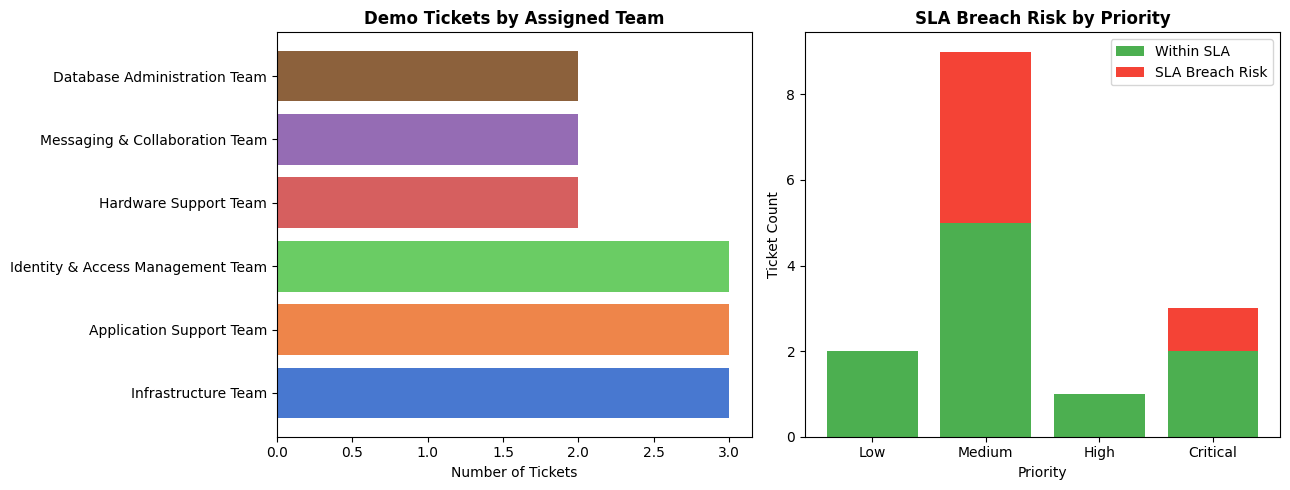

Saved: results/routing_demo_summary.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Assigned team distribution ────────────────────────────────────────────────
team_counts = results_df['assigned_team'].value_counts()
axes[0].barh(team_counts.index, team_counts.values,
             color=sns.color_palette('muted', len(team_counts)))
axes[0].set_title('Demo Tickets by Assigned Team', fontweight='bold')
axes[0].set_xlabel('Number of Tickets')

# ── SLA breach by priority ────────────────────────────────────────────────────
pri_breach = results_df.groupby('priority')['sla_breach_risk'].agg(['sum','count'])
pri_breach.columns = ['breach', 'total']
pri_breach['safe'] = pri_breach['total'] - pri_breach['breach']
pri_order = [p for p in ['Low','Medium','High','Critical'] if p in pri_breach.index]
pri_breach = pri_breach.reindex(pri_order)
axes[1].bar(pri_breach.index, pri_breach['safe'],   label='Within SLA',      color='#4caf50')
axes[1].bar(pri_breach.index, pri_breach['breach'],  label='SLA Breach Risk',
            bottom=pri_breach['safe'], color='#f44336')
axes[1].set_title('SLA Breach Risk by Priority', fontweight='bold')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Ticket Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'routing_demo_summary.png', bbox_inches='tight')
plt.show()
print('Saved: results/routing_demo_summary.png')

---
## 4. Single Ticket Deep-Dive

Tracing one ticket step-by-step — 


In [8]:
test_ticket = "production database PROD_DB is down since 8am, all transactions failing, urgent"
result = route_ticket(test_ticket)

print('='*60)
print('SINGLE TICKET ROUTING TRACE')
print('='*60)
print(f'Input : {test_ticket}')
print()
print(f'Step 2 — Category     : {result["category"]}')
print(f'Step 3 — Priority     : {result["priority"]}')
print(f'Step 4 — Est. Resolve : {result["predicted_resolution_hours"]} hours')
print()
print(f'Step 5 — Business Rules:')
print(f'  Assigned Team   : {result["assigned_team"]}')
print(f'  SLA Target      : {result["sla_target_hours"]} hours')
print(f'  SLA Breach Risk : {result["sla_breach_risk"]}')
print()
if result['sla_breach_risk']:
    print('  ACTION: ESCALATE IMMEDIATELY to on-call DBA and manager.')
else:
    print('  ACTION: Assign to queue. Monitor SLA timer.')

SINGLE TICKET ROUTING TRACE
Input : production database PROD_DB is down since 8am, all transactions failing, urgent

Step 2 — Category     : Database
Step 3 — Priority     : Critical
Step 4 — Est. Resolve : 20.5 hours

Step 5 — Business Rules:
  Assigned Team   : Database Administration Team
  SLA Target      : 4 hours
  SLA Breach Risk : True

  ACTION: ESCALATE IMMEDIATELY to on-call DBA and manager.


---
## 5. End-to-End Validation on Held-Out Test Set

In [9]:
import joblib, scipy.sparse as sp
from sklearn.metrics import classification_report

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

test_df = pd.read_csv(PROCESSED / 'test.csv')
le_cat  = joblib.load(MODELS_DIR / 'label_encoder_category.joblib')
le_pri  = joblib.load(MODELS_DIR / 'label_encoder_priority.joblib')
y_test_cat = np.load(str(PROCESSED / 'y_test_cat.npy'))
y_test_pri = np.load(str(PROCESSED / 'y_test_pri.npy'))

print('Running routing engine on full test set...')
test_results = batch_route(test_df['ticket_text'].tolist())
test_res_df  = pd.DataFrame(test_results)

pred_cats = le_cat.transform(test_res_df['category'])
pred_pris = le_pri.transform(test_res_df['priority'])

print('\nCategory classification (routing engine, test set):')
print(classification_report(y_test_cat, pred_cats, target_names=list(le_cat.classes_)))

print('\nPriority classification (routing engine, test set):')
print(classification_report(y_test_pri, pred_pris, target_names=list(le_pri.classes_)))

Running routing engine on full test set...



Category classification (routing engine, test set):
              precision    recall  f1-score   support

Access/Login       1.00      1.00      1.00       112
    Database       1.00      1.00      1.00        50
       Email       1.00      1.00      1.00        74
    Hardware       1.00      1.00      1.00        94
     Network       1.00      1.00      1.00       123
    Software       1.00      1.00      1.00       147

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Priority classification (routing engine, test set):
              precision    recall  f1-score   support

    Critical       0.29      0.21      0.24        48
        High       0.56      0.53      0.54       110
         Low       0.69      0.44      0.54       196
      Medium       0.58      0.80      0.67       246

    accuracy                           0.58       600
   macro avg       0.53  

---
## Project Complete

All seven notebooks have been built and run.

### Files produced by this project

| Folder | Files |
|---|---|
| `data/raw/` | `tickets.csv` (5 000 rows) |
| `data/processed/` | Feature matrices, label arrays, split CSVs |
| `models/` | TF-IDF vectorizer, W2V model, PCA, 3 best models, label encoders |
| `results/` | All metric CSVs and PNG plots |
| `notebooks/` | 7 runnable notebooks (01–07) |
| `src/` | `data_generation.py`, `preprocessing.py`, `models.py`, `routing_engine.py` |
| `app/` | `streamlit_app.py` (optional demo) |

**Next steps:**
1. Run `app/streamlit_app.py` for the interactive demo
2. Fill exact metric numbers into `SUMMARY.md`
3. Push to GitHub with `git push`